In [15]:
import pandas as pd
df = pd.read_csv(r"./simulation_results.csv")
print(df)

         Seed  Spawn_Strategy  \
0      965496               1   
1      965496               2   
2      965496               4   
3      965496               8   
4      965496              16   
...       ...             ...   
22183  905893               2   
22184  905893               4   
22185  905893               8   
22186  905893              16   
22187  905893              32   

                                       Initial_Drones_XY  Goal_X  Goal_Y  \
0                                             [(31, 31)]      53      49   
1                                   [(15, 31), (47, 31)]      53      49   
2               [(15, 15), (15, 47), (47, 15), (47, 47)]      53      49   
3      [(7, 15), (7, 47), (23, 15), (23, 47), (39, 15...      53      49   
4      [(7, 7), (7, 23), (7, 39), (7, 55), (23, 7), (...      53      49   
...                                                  ...     ...     ...   
22183                               [(15, 31), (47, 31)]      29      2

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

def plot_drone_spawn_heatmap(df: pd.DataFrame, n: int = 32):
    """
    pandas DataFrame을 입력받아 드론 초기 스폰 위치의 히트맵을 그리는 함수입니다.
    """
    # 1. n x n 크기의 빈 2차원 배열(0으로 채워짐) 생성
    heatmap_data = np.zeros((n, n), dtype=int)
    
    # 2. 드론 초기 좌표(Initial_Drones_XY) 카운트 누적
    for _, row in df.iterrows():
        # 문자열로 저장된 리스트 "[(x, y), ...]"를 실제 파이썬 리스트 객체로 변환
        drones_xy_list = ast.literal_eval(row['Initial_Drones_XY'])
        
        for x, y in drones_xy_list:
            # 미로 실제 좌표(1, 3, 5...)를 배열 인덱스(0, 1, 2...)로 변환
            grid_x = (x - 1) // 2
            grid_y = (y - 1) // 2
            heatmap_data[grid_x, grid_y] += 1

    # 3. 데이터 시각화 (히트맵)
    plt.figure(figsize=(10, 8))
    
    # 한글 폰트 설정 (윈도우: Malgun Gothic / 맥: AppleGothic)
    plt.rcParams['font.family'] = 'Malgun Gothic' 
    plt.rcParams['axes.unicode_minus'] = False
    
    # 드론 느낌이 나도록 파란색 톤(Blues)으로 설정
    sns.heatmap(heatmap_data, cmap="Blues", annot=False, cbar=True, square=True)
    
    plt.title(f"드론 초기 스폰(Spawn) 위치 누적 분포도 (n={n})", fontsize=15, pad=15)
    plt.xlabel("Y 좌표 (인덱스)", fontsize=12)
    plt.ylabel("X 좌표 (인덱스)", fontsize=12)
    plt.show()
    
    return heatmap_data



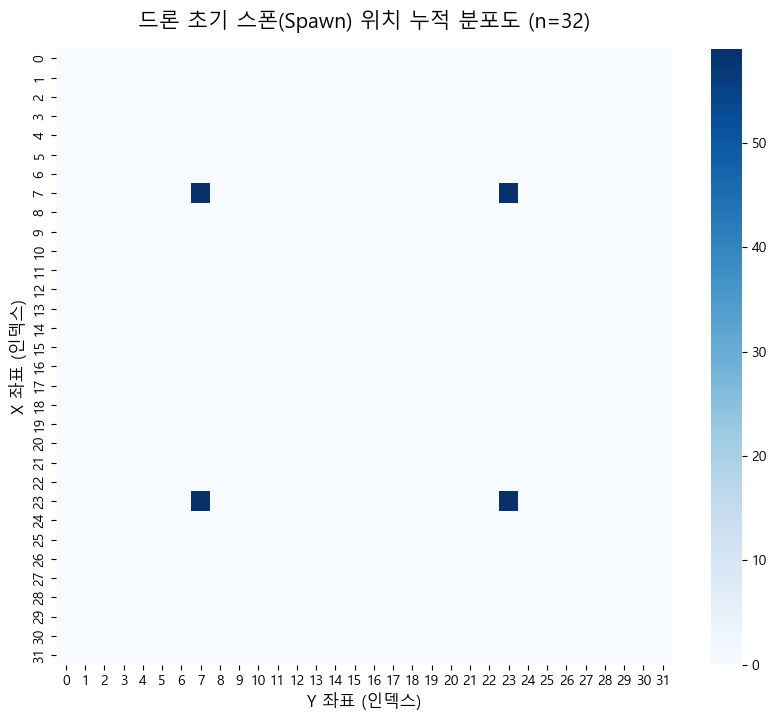

In [ ]:
heatmap_matrix = plot_drone_spawn_heatmap(df[df["Spawn_Strategy"] == 4])
#heatmap_matrix = plot_drone_spawn_heatmap(df[df["Spawn_Strategy"] == 32].iloc[[10]])

In [12]:
print(*df.columns, sep="\n")

Seed
Spawn_Strategy
Initial_Drones_XY
Goal_X
Goal_Y
Optimal_Tick
Used_Tick
Map_Coverage_%
Spawn_Fail_Count
Backtrack_Count
Total_Spawned
Success


In [14]:
print(df[df["Spawn_Strategy"] == "16"])

Empty DataFrame
Columns: [Seed, Spawn_Strategy, Initial_Drones_XY, Goal_X, Goal_Y, Optimal_Tick, Used_Tick, Map_Coverage_%, Spawn_Fail_Count, Backtrack_Count, Total_Spawned, Success]
Index: []
